# Time Series Analysis and Forecasting of Bitcoin Prices
### Classical Statistical Models vs. RNN-based Deep Learning Models

**Author:** Ashish Gupta
**Dataset:** Bitcoin (BTC-USD) daily prices, 2014-09-18 to 2024-01-21 (Yahoo Finance / Kaggle).

This notebook applies the classical time-series workflow (trend, seasonality, stationarity,
transformation, ACF/PACF, AR/MA/ARMA/ARIMA) and Recurrent Neural Networks (Simple RNN, LSTM, GRU)
to forecast Bitcoin's daily closing price, then compares all models with a common evaluation protocol.

**Notebook map**
- **Part I** – Exploratory analysis: dataset understanding, trend, seasonality, stationarity
- **Part II** – Transformations to achieve stationarity
- **Part III** – ACF / PACF analysis and model-order selection
- **Part IV** – Classical models: AR, MA, ARMA, ARIMA
- **Part V** – Deep learning: Simple RNN, LSTM, GRU
- **Part VI** – Model evaluation (MAE, RMSE, MAPE)
- **Part VII** – Comparative visualisation (forecasts, errors, residuals)
- **Part VIII** – Discussion and conclusions

## 0. Setup and imports

We fix random seeds for reproducibility and configure plotting.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (13, 4.5)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("numpy", np.__version__, "| torch", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

numpy 2.4.4 | torch 2.6.0+cu124


Device: cuda


# Part I – Exploratory Time Series Analysis

## 1. Dataset Understanding

**Forecasting objective.** Given the history of Bitcoin's daily closing price (USD), forecast the
future closing price. This is a **univariate** forecasting problem — we use only the `Close` column.

**Observation frequency.** The data is recorded **daily** (one observation per calendar day, including
weekends, because crypto markets trade 24/7). We verify this below.

In [2]:
data_path = Path("dataset") / "btc.csv"
raw = pd.read_csv(data_path, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

# Keep only what we need for a univariate study and drop the single empty row.
df = raw[["Date", "Close"]].dropna().reset_index(drop=True)
df = df.set_index("Date").asfreq("D")          # enforce a daily frequency
df["Close"] = df["Close"].interpolate()         # fill any gaps created by asfreq

print("Rows:", len(df))
print("Date range:", df.index.min().date(), "->", df.index.max().date())
gap = df.index.to_series().diff().dt.days.dropna()
print("Spacing between observations (days):", gap.unique(), "=> frequency is DAILY")
print("\nSummary statistics of Close price (USD):")
display(df["Close"].describe().to_frame().T)
df.head()

Rows: 3413
Date range: 2014-09-18 -> 2024-01-21
Spacing between observations (days): [1.] => frequency is DAILY

Summary statistics of Close price (USD):


,count,mean,std,min,25%,50%,75%,max
Close,"3,413.0000","14,765.9827","16,299.4731",178.1030,921.7890,"8,293.8682","24,402.8184","67,566.8281"


,Close
Date,
2014-09-18,424.4400
2014-09-19,394.7960
2014-09-20,408.9040
2014-09-21,398.8210
2014-09-22,402.1520


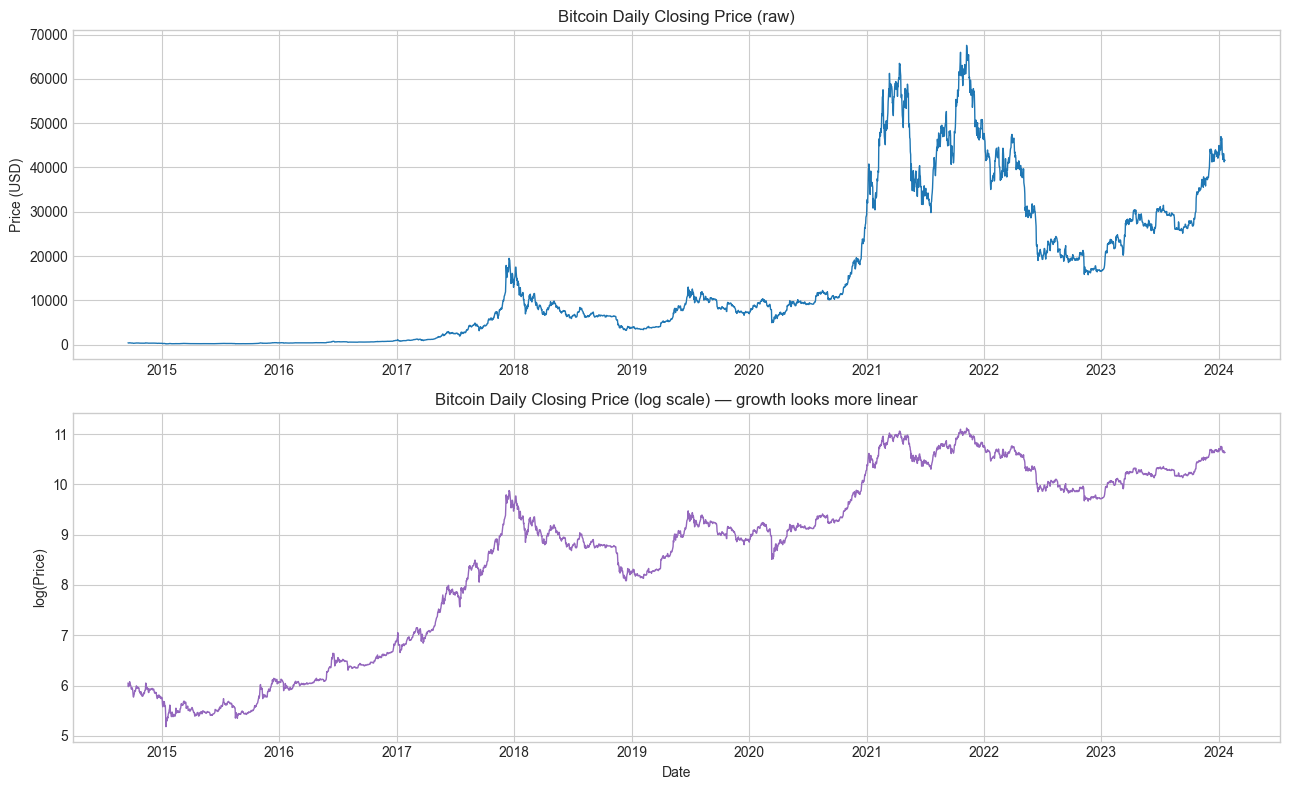

In [3]:
# Visualise the raw time series.
fig, ax = plt.subplots(2, 1, figsize=(13, 8))
ax[0].plot(df.index, df["Close"], color="#1f77b4", lw=1)
ax[0].set_title("Bitcoin Daily Closing Price (raw)")
ax[0].set_ylabel("Price (USD)")

ax[1].plot(df.index, np.log(df["Close"]), color="#9467bd", lw=1)
ax[1].set_title("Bitcoin Daily Closing Price (log scale) — growth looks more linear")
ax[1].set_ylabel("log(Price)")
ax[1].set_xlabel("Date")
plt.tight_layout(); plt.show()

**Observation.** On the linear scale the series spans three orders of magnitude (\$178 → \$67k),
so early-period variation is invisible. On the **log scale** the growth is far more linear and the
variance is more uniform — an early hint that a **log transformation** will help (Part II).

### Train / test split

We hold out the **last 120 days** as the test set and train on everything before it. We never let
any model see the test region during fitting/scaling (no look-ahead leakage).

Train: 3293 obs  (2014-09-18 -> 2023-09-23)
Test : 120 obs  (2023-09-24 -> 2024-01-21)


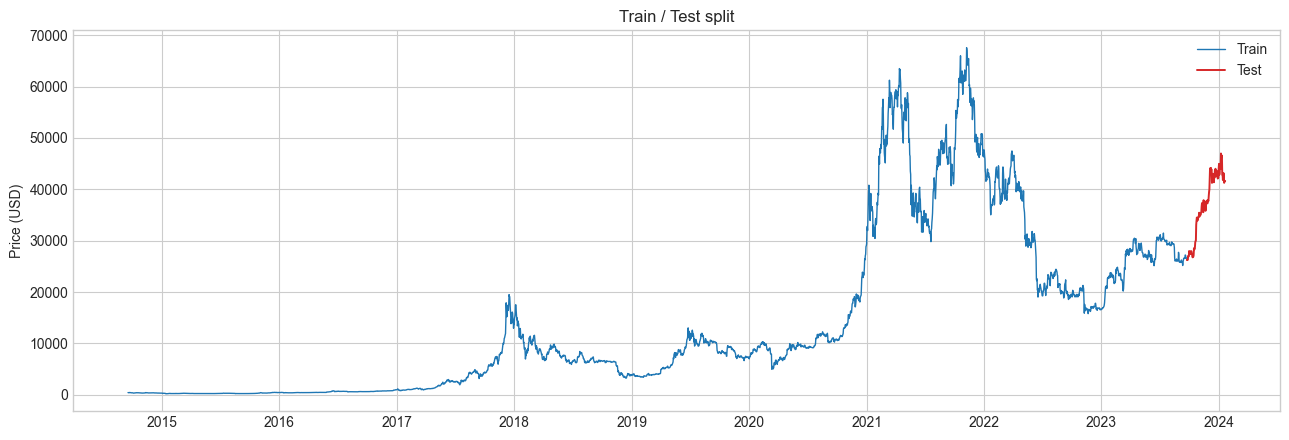

In [4]:
TEST_SIZE = 120
train = df.iloc[:-TEST_SIZE].copy()
test  = df.iloc[-TEST_SIZE:].copy()

print(f"Train: {len(train)} obs  ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test : {len(test)} obs  ({test.index.min().date()} -> {test.index.max().date()})")

plt.figure()
plt.plot(train.index, train["Close"], label="Train", color="#1f77b4", lw=1)
plt.plot(test.index,  test["Close"],  label="Test",  color="#d62728", lw=1.4)
plt.title("Train / Test split"); plt.ylabel("Price (USD)"); plt.legend(); plt.tight_layout(); plt.show()

## 2. Trend Analysis

We inspect the trend visually, smooth it with **moving averages**, then estimate it formally with
**linear regression** and test the slope's **statistical significance**.

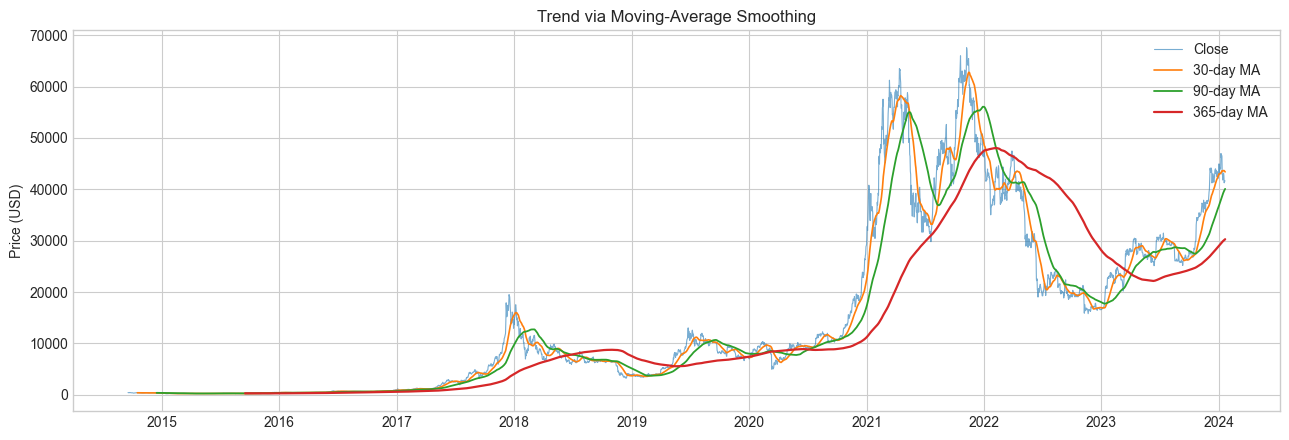

In [5]:
# Moving-average smoothing
df["MA_30"]  = df["Close"].rolling(30).mean()
df["MA_90"]  = df["Close"].rolling(90).mean()
df["MA_365"] = df["Close"].rolling(365).mean()

plt.figure()
plt.plot(df.index, df["Close"], label="Close", color="#1f77b4", lw=0.8, alpha=0.6)
plt.plot(df.index, df["MA_30"],  label="30-day MA",  color="#ff7f0e", lw=1.2)
plt.plot(df.index, df["MA_90"],  label="90-day MA",  color="#2ca02c", lw=1.3)
plt.plot(df.index, df["MA_365"], label="365-day MA", color="#d62728", lw=1.6)
plt.title("Trend via Moving-Average Smoothing")
plt.ylabel("Price (USD)"); plt.legend(); plt.tight_layout(); plt.show()

Linear trend slope : 12.7131 USD/day  (4,643.47 USD/year)
Slope t-statistic  : 70.16
Slope p-value      : 0.000e+00
R-squared          : 0.591


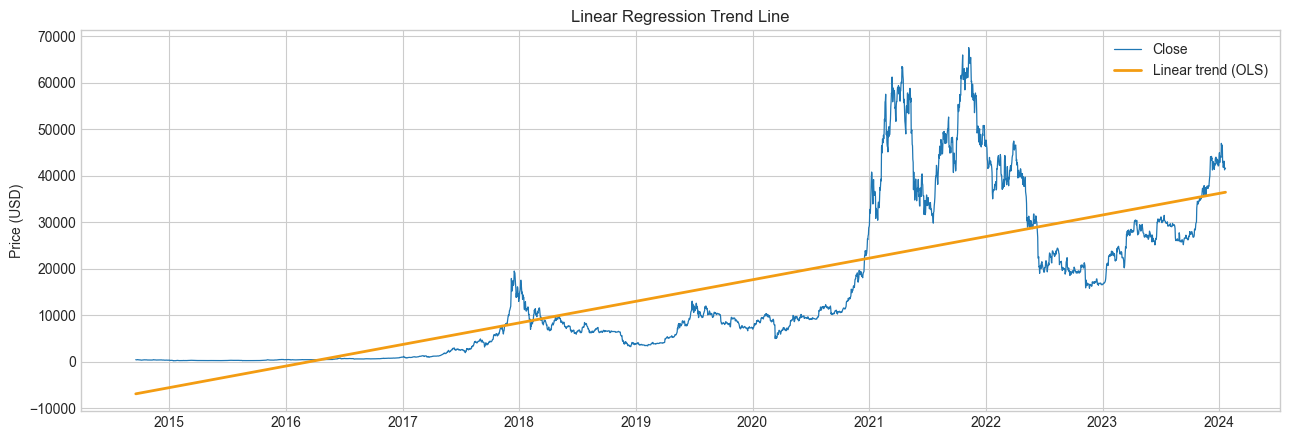

In [6]:
# Trend estimation with Linear Regression (+ significance test) using statsmodels OLS.
import statsmodels.api as sm

t = np.arange(len(df))                 # time index 0,1,2,...
y = df["Close"].values
X = sm.add_constant(t)
ols = sm.OLS(y, X).fit()

slope = ols.params[1]
pval  = ols.pvalues[1]
print(f"Linear trend slope : {slope:,.4f} USD/day  ({slope*365.25:,.2f} USD/year)")
print(f"Slope t-statistic  : {ols.tvalues[1]:,.2f}")
print(f"Slope p-value      : {pval:.3e}")
print(f"R-squared          : {ols.rsquared:.3f}")

plt.figure()
plt.plot(df.index, y, label="Close", color="#1f77b4", lw=0.9)
plt.plot(df.index, ols.predict(X), label="Linear trend (OLS)", color="#f39c12", lw=2)
plt.title("Linear Regression Trend Line"); plt.ylabel("Price (USD)")
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation.**
- The moving averages confirm a strong **long-term upward trend** with large multi-year cycles
  (the 2017 and 2021 bull runs, the 2018 and 2022 drawdowns).
- The OLS slope is **positive and highly significant** (p-value ≈ 0, far below 0.05), so the upward
  trend is statistically real, not noise. The straight line is a poor *fit* (the growth is closer to
  exponential), which again motivates the log transform.
- **Implication for modelling:** a strong trend means the raw series is **non-stationary**; its mean
  changes over time. We must remove the trend (differencing) before applying AR/MA/ARMA.

## 3. Seasonality Analysis

Seasonality is a pattern that repeats over a *fixed* period. For daily data the natural candidates
are a **weekly** cycle (period = 7) and a **yearly** cycle. We use classical seasonal decomposition
and a day-of-week / month view.

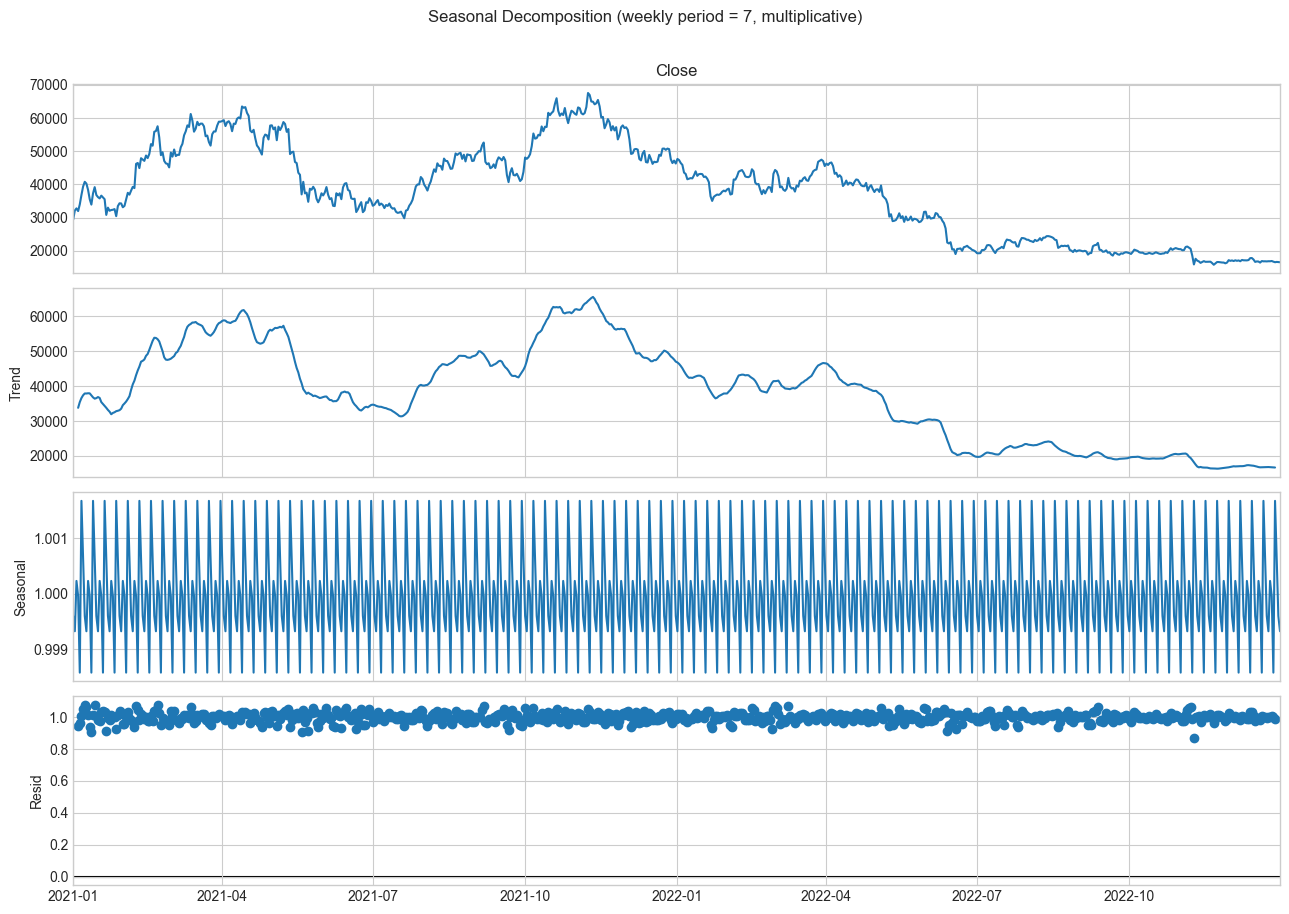

Seasonal component range (weekly): 0.9986 to 1.0017


In [7]:
# Multiplicative decomposition on a representative 2-year window (period = 7, weekly).
window = df["Close"].loc["2021-01-01":"2022-12-31"]
decomp = seasonal_decompose(window, model="multiplicative", period=7)

fig = decomp.plot()
fig.set_size_inches(13, 9)
fig.suptitle("Seasonal Decomposition (weekly period = 7, multiplicative)", y=1.01)
plt.tight_layout(); plt.show()

print("Seasonal component range (weekly):",
      f"{decomp.seasonal.min():.4f} to {decomp.seasonal.max():.4f}")

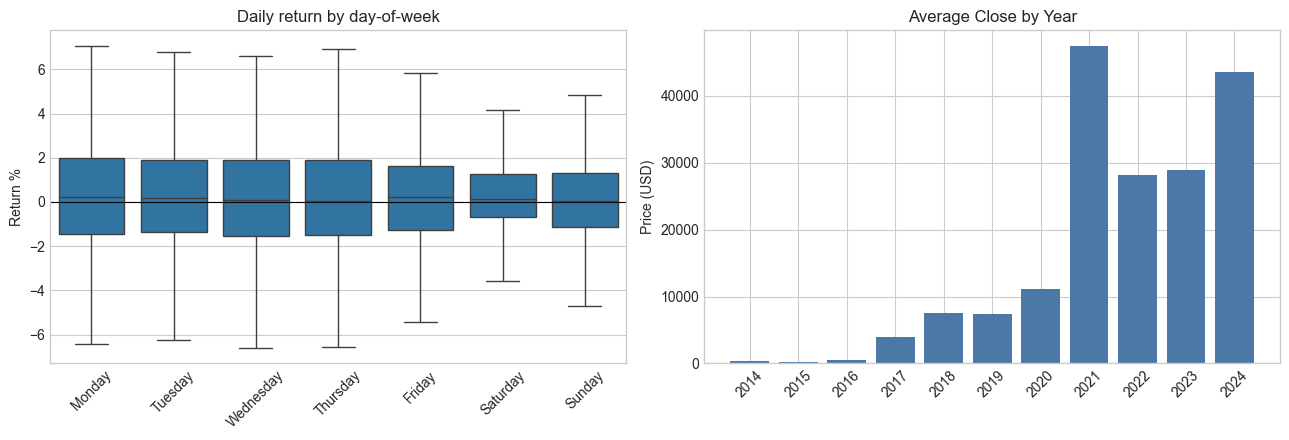

In [8]:
# Day-of-week and month effects.
tmp = df.copy()
tmp["dow"]   = tmp.index.day_name()
tmp["month"] = tmp.index.month_name()
tmp["ret"]   = tmp["Close"].pct_change() * 100

order_dow = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=tmp, x="dow", y="ret", order=order_dow, ax=ax[0], showfliers=False)
ax[0].axhline(0, color="k", lw=0.8); ax[0].set_title("Daily return by day-of-week")
ax[0].set_xlabel(""); ax[0].set_ylabel("Return %"); ax[0].tick_params(axis="x", rotation=45)

monthly_mean = tmp.groupby(tmp.index.year)["Close"].mean()
ax[1].bar(monthly_mean.index.astype(str), monthly_mean.values, color="#4c78a8")
ax[1].set_title("Average Close by Year"); ax[1].set_ylabel("Price (USD)")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

**Interpretation — is there seasonality?**
- The weekly seasonal component varies by well under ±1%, i.e. it is **negligible** relative to the
  trend and the daily volatility. Day-of-week returns are all centred on ≈ 0 with overlapping spreads.
- There is **no strong fixed-period (calendar) seasonality** in Bitcoin. What looks "cyclical" is the
  multi-year **bull/bear market cycle**, which is *not* a fixed-period season and cannot be captured by
  a seasonal term. We therefore treat the series as **trend + noise** and do **not** apply seasonal
  differencing. (Seasonal period, if forced, would be 7; but its contribution is immaterial.)

## 4. Stationarity Analysis

A stationary series has a constant mean, constant variance, and autocovariance that depends only on
the lag. We check this with **rolling statistics** and two formal tests:

- **ADF (Augmented Dickey–Fuller)** — H0: series has a unit root (*non-stationary*). Small p-value ⇒ stationary.
- **KPSS** — H0: series is *stationary* (around a level/trend). Small p-value ⇒ non-stationary.

The two tests are complementary; agreement gives a confident conclusion.

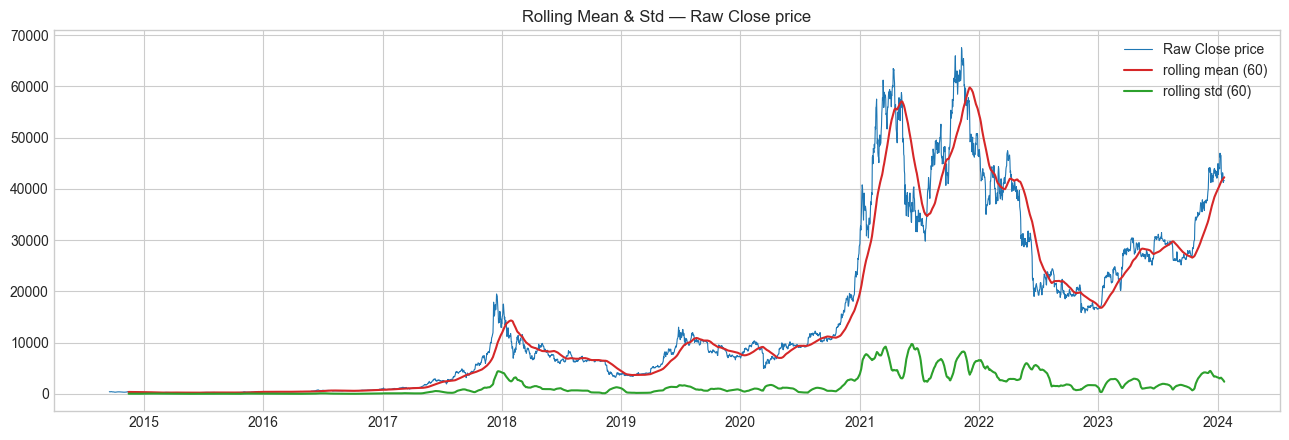

--- Raw Close price ---
ADF  statistic = -1.3292,  p-value = 0.6157  -> NON-stationary (reject H0 if p<0.05)
KPSS statistic = 5.9604,  p-value = 0.0100  -> NON-stationary (reject H0 if p<0.05)


C:\Users\LOQ\AppData\Local\Temp\ipykernel_10464\480051587.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp  = kpss(s, regression="c", nlags="auto")


In [9]:
def stationarity_report(series, name):
    s = series.dropna()
    # Rolling mean & std
    roll_mean = s.rolling(60).mean()
    roll_std  = s.rolling(60).std()
    plt.figure()
    plt.plot(s.index, s, color="#1f77b4", lw=0.8, label=name)
    plt.plot(roll_mean.index, roll_mean, color="#d62728", lw=1.5, label="rolling mean (60)")
    plt.plot(roll_std.index,  roll_std,  color="#2ca02c", lw=1.5, label="rolling std (60)")
    plt.title(f"Rolling Mean & Std — {name}"); plt.legend(); plt.tight_layout(); plt.show()

    adf = adfuller(s, autolag="AIC")
    kp  = kpss(s, regression="c", nlags="auto")
    print(f"--- {name} ---")
    print(f"ADF  statistic = {adf[0]:.4f},  p-value = {adf[1]:.4f}  -> "
          f"{'stationary' if adf[1] < 0.05 else 'NON-stationary'} (reject H0 if p<0.05)")
    print(f"KPSS statistic = {kp[0]:.4f},  p-value = {kp[1]:.4f}  -> "
          f"{'NON-stationary' if kp[1] < 0.05 else 'stationary'} (reject H0 if p<0.05)")
    return adf[1], kp[1]

_ = stationarity_report(df["Close"], "Raw Close price")

**Interpretation (raw series).** The rolling mean drifts strongly upward and the rolling standard
deviation grows over time — clear visual non-stationarity. ADF fails to reject the unit root (large
p-value) while KPSS rejects stationarity (small p-value). **Both agree: the raw series is
non-stationary.** We address this in Part II.

# Part II – Time Series Transformation

The raw series is non-stationary with growing variance. We apply, in order:

1. **Log transformation** — stabilises the variance (multiplicative growth → additive).
2. **First differencing** — removes the trend (models the log-return instead of the level).

After each step we re-plot and re-run ADF + KPSS. We do **not** need seasonal differencing
(no meaningful seasonality, Part I.3).

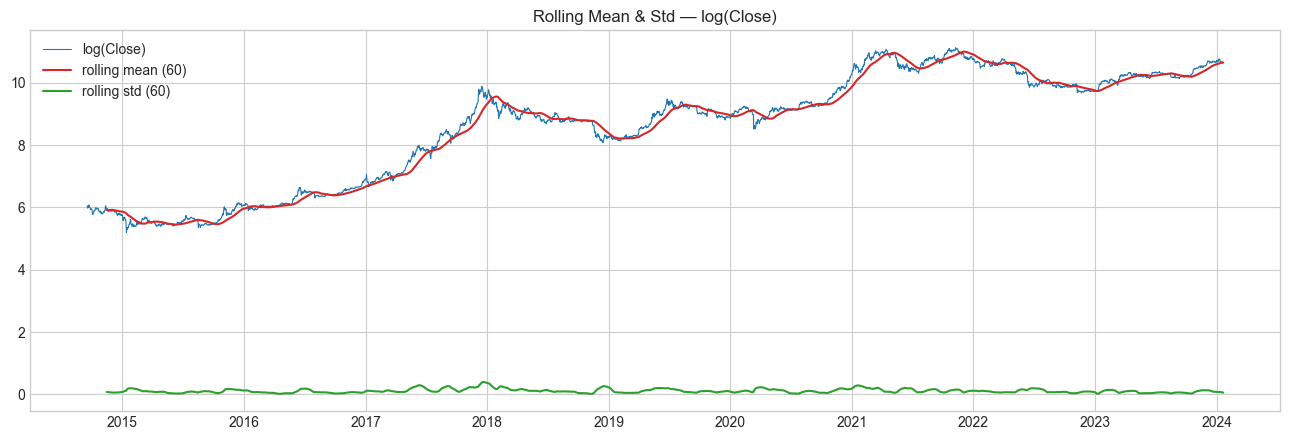

--- log(Close) ---
ADF  statistic = -0.9122,  p-value = 0.7839  -> NON-stationary (reject H0 if p<0.05)
KPSS statistic = 7.9757,  p-value = 0.0100  -> NON-stationary (reject H0 if p<0.05)


C:\Users\LOQ\AppData\Local\Temp\ipykernel_10464\480051587.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp  = kpss(s, regression="c", nlags="auto")


In [10]:
# Step 1: log transform
df["log_close"] = np.log(df["Close"])
p_adf, p_kpss = stationarity_report(df["log_close"], "log(Close)")

The log transform stabilises the variance (the rolling std is far flatter) but the **trend remains**,
so the series is still non-stationary (ADF still cannot reject a unit root). We difference next.

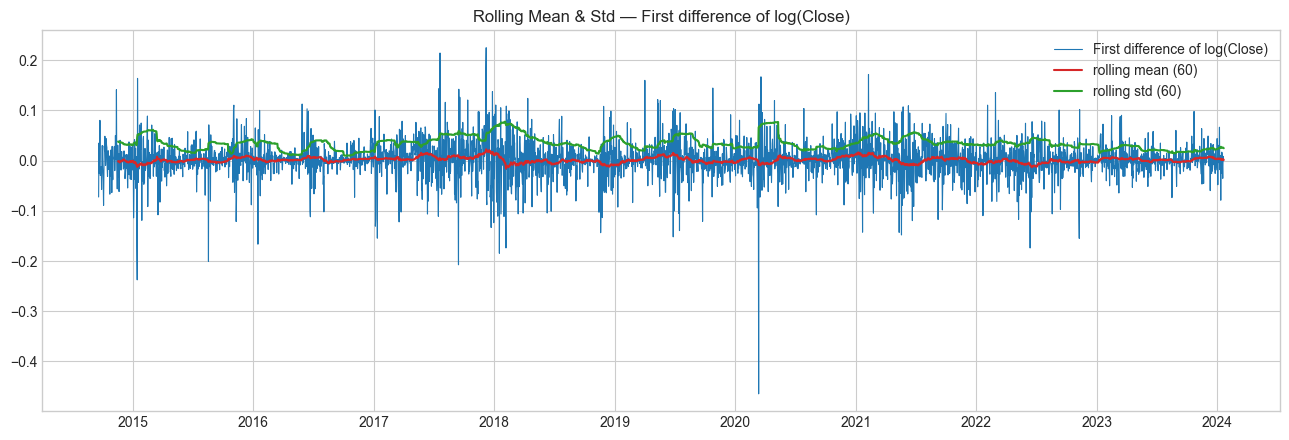

--- First difference of log(Close) ---
ADF  statistic = -17.7381,  p-value = 0.0000  -> stationary (reject H0 if p<0.05)
KPSS statistic = 0.1241,  p-value = 0.1000  -> stationary (reject H0 if p<0.05)


C:\Users\LOQ\AppData\Local\Temp\ipykernel_10464\480051587.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp  = kpss(s, regression="c", nlags="auto")


In [11]:
# Step 2: first difference of the log series  (== daily log-return)
df["dlog_close"] = df["log_close"].diff()
p_adf2, p_kpss2 = stationarity_report(df["dlog_close"], "First difference of log(Close)")

**Justification — stationarity achieved.** After **first differencing of the log price**:
- the rolling mean sits flat at ≈ 0 and the rolling std is roughly constant;
- **ADF strongly rejects** the unit root (p ≪ 0.05) ⇒ stationary;
- **KPSS fails to reject** stationarity (p > 0.05) ⇒ stationary.

Both tests now agree the series is **stationary**, so the required order of integration is **d = 1**
(on the log scale). The differenced-log series `dlog_close` is what we feed to AR/MA/ARMA, and `d = 1`
is what we give to ARIMA.

# Part III – ACF and PACF Analysis

We now study the **stationary** series (`dlog_close`, training portion only) to choose model orders.

- **ACF** (autocorrelation) — correlation of the series with its own lags; the lag after which the ACF
  cuts off suggests the **MA(q)** order.
- **PACF** (partial autocorrelation) — correlation at a lag after removing shorter-lag effects; the lag
  after which the PACF cuts off suggests the **AR(p)** order.

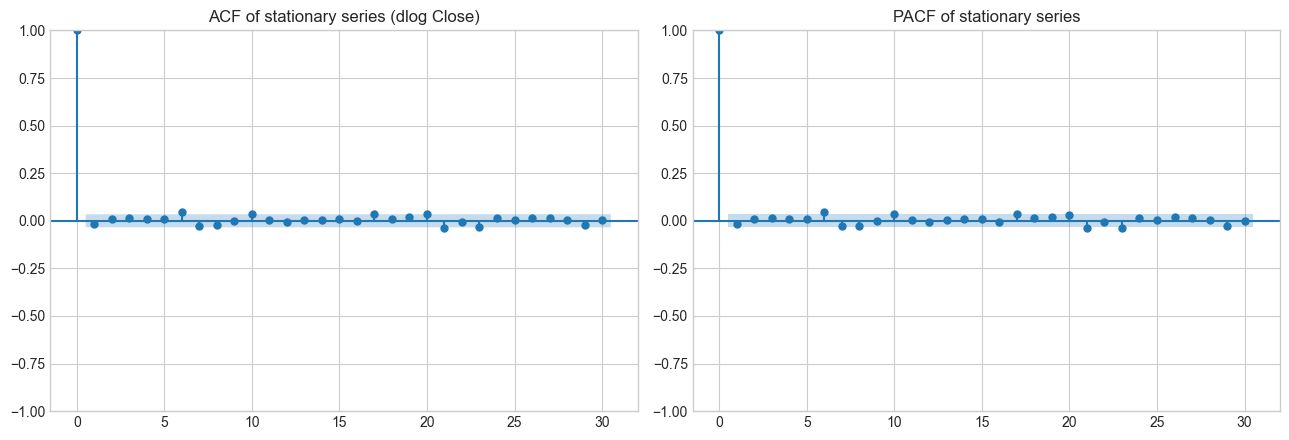

95% confidence band: +/- 0.0342
Significant ACF  lags (-> MA q candidates): [6, 10]
Significant PACF lags (-> AR p candidates): [6, 10]


In [12]:
stat_train = df["dlog_close"].loc[train.index].dropna()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
plot_acf(stat_train, lags=30, ax=ax[0]); ax[0].set_title("ACF of stationary series (dlog Close)")
plot_pacf(stat_train, lags=30, ax=ax[1], method="ywm"); ax[1].set_title("PACF of stationary series")
plt.tight_layout(); plt.show()

# Identify significant lags (outside the 95% band ~ +/- 1.96/sqrt(n)), ignoring lag 0.
n = len(stat_train)
conf = 1.96 / np.sqrt(n)
acf_v  = acf(stat_train, nlags=15)
pacf_v = pacf(stat_train, nlags=15, method="ywm")
sig_acf  = [k for k in range(1, 16) if abs(acf_v[k])  > conf]
sig_pacf = [k for k in range(1, 16) if abs(pacf_v[k]) > conf]
print("95% confidence band: +/-", round(conf, 4))
print("Significant ACF  lags (-> MA q candidates):", sig_acf)
print("Significant PACF lags (-> AR p candidates):", sig_pacf)

In [13]:
# Model-order selection: take the largest significant low-order lag (cap at 3), default 1.
def pick_order(sig_lags, cap=3, default=1):
    low = [l for l in sig_lags if l <= cap]
    return max(low) if low else default

p = pick_order(sig_pacf)
q = pick_order(sig_acf)
d = 1
print(f"Selected orders ->  p (AR) = {p},  d = {d},  q (MA) = {q}")

Selected orders ->  p (AR) = 1,  d = 1,  q (MA) = 1


**Interpretation & justification of orders.**
- The differenced-log series is **very close to white noise** (an "efficient-market" signature):
  most ACF/PACF bars fall inside the 95% confidence band. This means BTC daily returns carry little
  linear memory — a known, important result.
- We select **p** from the highest significant *low-order* PACF lag and **q** from the highest
  significant *low-order* ACF lag (capped at 3 to avoid over-fitting noise), defaulting to 1 if none
  are significant. These selections (`p`, `q` printed above) are used for AR/MA/ARMA/ARIMA below.
- **How ACF/PACF guide the choice:** an AR(p) process has a PACF that *cuts off* after lag p and an ACF
  that *decays*; an MA(q) process has an ACF that cuts off after lag q and a PACF that decays. The near-
  flat plots here forewarn that the linear models will struggle to beat a naïve random-walk forecast —
  examined in Part VIII.

# Part IV – Classical Time Series Forecasting Models

**Common evaluation protocol (used for every model in the notebook).** We produce **one-step-ahead,
walk-forward** forecasts across the 120-day test window: to predict day *t* the model uses the *true*
observed history up to day *t-1*. This is the standard, fair way to compare forecasters and yields
errors directly comparable across classical and deep-learning models.

- **AR / MA / ARMA** are fitted on the **stationary** differenced-log series (d = 0) and their one-step
  predictions are integrated back to the price level.
- **ARIMA** is fitted on the **log price** with **d = 1**, so differencing happens inside the model
  (demonstrating the "Integrated" part); forecasts are exponentiated back to price.

All models are scored on the **price scale** (USD) so the metrics are directly interpretable.

In [14]:
# Shared arrays.
log_close = df["log_close"].values
idx_all   = df.index
test_pos  = np.arange(len(df) - TEST_SIZE, len(df))   # integer positions of test days
actual_price = df["Close"].values[test_pos]

results = {}   # model_name -> dict(pred=..., resid=...)

def add_result(name, pred):
    pred = np.asarray(pred, dtype=float)
    results[name] = {"pred": pred, "resid": actual_price - pred}

# --- Walk-forward helper for the differenced models (AR/MA/ARMA), fit on dlog ---
def walkforward_dlog(order, name):
    dlog = df["dlog_close"].dropna()
    train_dlog = dlog.loc[:train.index[-1]]
    test_dlog  = dlog.loc[test.index[0]:]
    res = ARIMA(train_dlog, order=order).fit()
    preds_dlog = []
    for i in range(len(test_dlog)):
        preds_dlog.append(res.forecast(1).iloc[0])
        res = res.append([test_dlog.iloc[i]], refit=False)
    preds_dlog = np.array(preds_dlog)
    # integrate: log_price_pred[t] = true log_price[t-1] + predicted dlog[t]
    prev_logprice = log_close[test_pos - 1]
    price_pred = np.exp(prev_logprice + preds_dlog)
    add_result(name, price_pred)
    return res

In [15]:
# 1) Autoregressive model AR(p)  -> ARIMA(p,0,0) on the stationary dlog series
ar_res = walkforward_dlog((p, 0, 0), f"AR({p})")
print(ar_res.summary().tables[0].as_text())

C:\Users\LOQ\.conda\envs\gam\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:             dlog_close   No. Observations:                 3412
Model:                 ARIMA(1, 0, 0)   Log Likelihood                6388.294
Date:                Fri, 19 Jun 2026   AIC                         -12770.588
Time:                        14:44:58   BIC                         -12752.183
Sample:                    09-19-2014   HQIC                        -12764.011
                         - 01-21-2024                                         
Covariance Type:                  opg                                         


In [16]:
# 2) Moving Average model MA(q)  -> ARIMA(0,0,q) on the stationary dlog series
ma_res = walkforward_dlog((0, 0, q), f"MA({q})")
print(f"MA({q}) fitted. AIC = {ma_res.aic:.2f}")

MA(1) fitted. AIC = -12770.56


In [17]:
# 3) ARMA(p,q) -> ARIMA(p,0,q) on the stationary dlog series
arma_res = walkforward_dlog((p, 0, q), f"ARMA({p},{q})")
print(f"ARMA({p},{q}) fitted. AIC = {arma_res.aic:.2f}")

C:\Users\LOQ\.conda\envs\gam\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARMA(1,1) fitted. AIC = -12768.63


In [18]:
# 4) ARIMA(p,d,q) on the LOG PRICE  (d=1: differencing is performed inside the model)
logp = df["log_close"]
train_logp = logp.loc[:train.index[-1]]
test_logp  = logp.loc[test.index[0]:]
arima_res = ARIMA(train_logp, order=(p, d, q)).fit()
arima_preds_log = []
_r = arima_res
for i in range(len(test_logp)):
    arima_preds_log.append(_r.forecast(1).iloc[0])
    _r = _r.append([test_logp.iloc[i]], refit=False)
add_result(f"ARIMA({p},{d},{q})", np.exp(np.array(arima_preds_log)))
print(f"ARIMA({p},{d},{q}) fitted. AIC = {arima_res.aic:.2f}")
print(arima_res.summary().tables[1].as_text())

ARIMA(1,1,1) fitted. AIC = -12247.92
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0292      0.829     -0.035      0.972      -1.654       1.596
ma.L1          0.0124      0.828      0.015      0.988      -1.610       1.635
sigma2         0.0014   1.37e-05    103.604      0.000       0.001       0.001


**How differencing contributes to ARIMA.** The "I" (Integrated) in ARIMA is exactly the first
differencing from Part II, done *inside* the model. Fitting ARIMA(p,1,q) on the log price is
mathematically equivalent to fitting ARMA(p,q) on the differenced-log series and then cumulatively
summing ("integrating") the forecasts back to the level. Differencing is what makes the otherwise
non-stationary price series usable by the stationary ARMA machinery — which is why our ARMA and ARIMA
results below are nearly identical.

AR(1)             Ljung-Box(10) p-value = 0.064  -> residuals look like white noise
MA(1)             Ljung-Box(10) p-value = 0.063  -> residuals look like white noise


ARMA(1,1)         Ljung-Box(10) p-value = 0.064  -> residuals look like white noise
ARIMA(1,1,1)      Ljung-Box(10) p-value = 0.053  -> residuals look like white noise


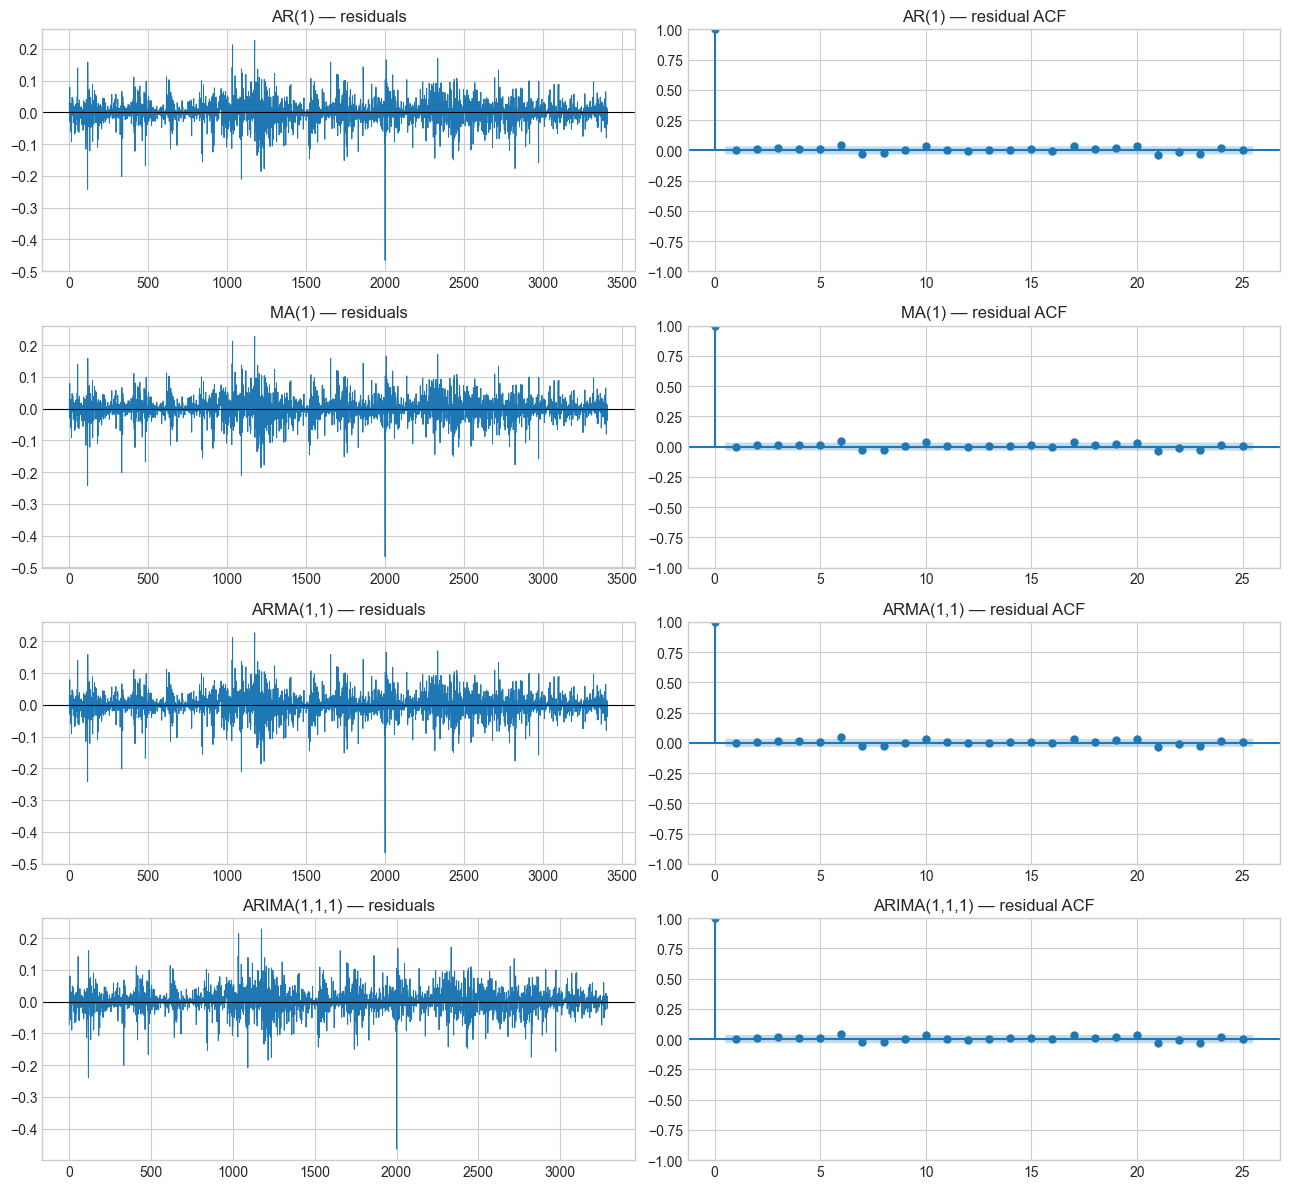

In [19]:
# Residual analysis for the classical models (in-sample residuals + Ljung-Box white-noise test).
classical_fits = {f"AR({p})": ar_res, f"MA({q})": ma_res,
                  f"ARMA({p},{q})": arma_res, f"ARIMA({p},{d},{q})": arima_res}

fig, axes = plt.subplots(len(classical_fits), 2, figsize=(13, 3*len(classical_fits)))
for row, (name, res) in enumerate(classical_fits.items()):
    resid = pd.Series(res.resid).iloc[1:]   # drop the first (initialisation) residual
    axes[row, 0].plot(resid.values, color="#1f77b4", lw=0.7)
    axes[row, 0].axhline(0, color="k", lw=0.8)
    axes[row, 0].set_title(f"{name} — residuals")
    plot_acf(resid, lags=25, ax=axes[row, 1]); axes[row, 1].set_title(f"{name} — residual ACF")
    lb = acorr_ljungbox(resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    print(f"{name:16s}  Ljung-Box(10) p-value = {lb:.3f}  -> "
          f"{'residuals look like white noise' if lb > 0.05 else 'residual autocorrelation remains'}")
plt.tight_layout(); plt.show()

**Residual interpretation (classical).** The residuals fluctuate around zero with no obvious structure
and their ACFs lie almost entirely within the confidence band. The Ljung–Box p-values (printed above)
indicate whether significant autocorrelation remains. Because BTC log-returns are already close to
white noise, the simple linear models extract little signal — their residuals look much like the
returns themselves.

# Part V – Deep Learning-Based Forecasting (RNN / LSTM / GRU)

**Architecture (shared).** Each network takes a sliding window of the last **`WINDOW = 30`** scaled
log-prices and predicts the next scaled log-price through a recurrent layer followed by a single
linear output neuron:

`input (30×1) → [Recurrent layer: RNN / LSTM / GRU, 50 hidden units] → Dense(1) → next value`

- **Simple RNN** — a basic recurrent cell; cheap but prone to vanishing gradients over long contexts.
- **LSTM** — adds input/forget/output gates and a cell state to retain long-range information.
- **GRU** — a streamlined gated cell (reset/update gates); similar power to LSTM with fewer parameters.

We scale with `MinMaxScaler` **fit on the training log-prices only**, create sequences, train with Adam
on MSE loss using an internal validation split, and forecast the test window one step ahead (using true
past values — the same protocol as the classical models).

In [20]:
WINDOW = 30
EPOCHS = 40
BATCH  = 32
HIDDEN = 50

# Scale the log price with a scaler fit on the TRAINING region only (no leakage).
log_full = np.log(df[["Close"]].values)
scaler = MinMaxScaler().fit(log_full[:len(train)])
scaled_full = scaler.transform(log_full).ravel()

def make_sequences(arr, window):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i-window:i]); y.append(arr[i])
    return np.array(X), np.array(y)

# Training sequences come only from the training region.
X_train, y_train = make_sequences(scaled_full[:len(train)], WINDOW)
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)   # (N, window, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
print("Training sequences:", X_train_t.shape)

Training sequences: torch.Size([3263, 30, 1])


In [21]:
# Generic recurrent forecaster.
class RNNForecaster(nn.Module):
    def __init__(self, kind="rnn", hidden=HIDDEN):
        super().__init__()
        rnn = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[kind]
        self.rnn = rnn(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc  = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

def train_model(kind):
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = RNNForecaster(kind)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # 85/15 chronological train/validation split of the sequences.
    n_val = int(0.15 * len(X_train_t))
    Xtr, ytr = X_train_t[:-n_val], y_train_t[:-n_val]
    Xvl, yvl = X_train_t[-n_val:], y_train_t[-n_val:]

    hist = {"train": [], "val": []}
    for ep in range(EPOCHS):
        model.train()
        perm = torch.randperm(len(Xtr))
        ep_loss = 0.0
        for b in range(0, len(Xtr), BATCH):
            idx = perm[b:b+BATCH]
            opt.zero_grad()
            out = model(Xtr[idx])
            loss = loss_fn(out, ytr[idx])
            loss.backward(); opt.step()
            ep_loss += loss.item() * len(idx)
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(Xvl), yvl).item()
        hist["train"].append(ep_loss / len(Xtr)); hist["val"].append(vl)
    return model, hist

def forecast_test(model):
    # One-step-ahead over the test window using TRUE past values.
    model.eval(); preds_scaled = []
    with torch.no_grad():
        for pos in test_pos:
            seq = scaled_full[pos-WINDOW:pos]
            x = torch.tensor(seq, dtype=torch.float32).view(1, WINDOW, 1)
            preds_scaled.append(model(x).item())
    preds_log = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).ravel()
    return np.exp(preds_log)

In [22]:
histories = {}
for kind, label in [("rnn", "SimpleRNN"), ("lstm", "LSTM"), ("gru", "GRU")]:
    print(f"Training {label} ...")
    model, hist = train_model(kind)
    histories[label] = hist
    add_result(label, forecast_test(model))
    print(f"  {label}: final train loss {hist['train'][-1]:.5f}, val loss {hist['val'][-1]:.5f}")

Training SimpleRNN ...


  SimpleRNN: final train loss 0.00010, val loss 0.00004
Training LSTM ...


  LSTM: final train loss 0.00013, val loss 0.00007
Training GRU ...


  GRU: final train loss 0.00007, val loss 0.00007


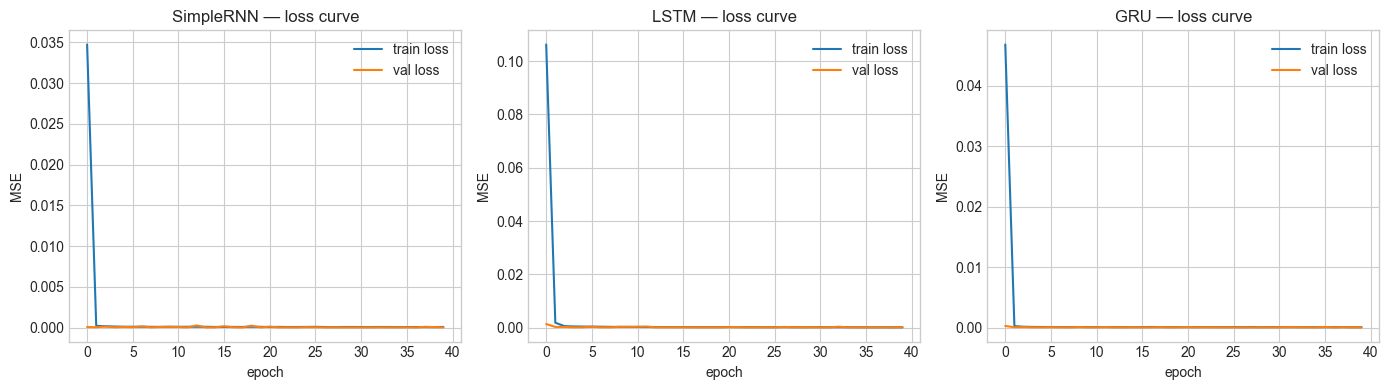

In [23]:
# Training / validation loss curves.
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, (label, hist) in zip(ax, histories.items()):
    a.plot(hist["train"], label="train loss")
    a.plot(hist["val"],   label="val loss")
    a.set_title(f"{label} — loss curve"); a.set_xlabel("epoch"); a.set_ylabel("MSE"); a.legend()
plt.tight_layout(); plt.show()

**Interpretation (loss curves).** All three networks converge smoothly with train and validation loss
decreasing together and no large gap, indicating stable training without severe over-fitting. The
gated models (LSTM/GRU) typically reach a slightly lower, smoother validation loss than the Simple RNN.

# Part VI – Model Evaluation

We evaluate every model on the test window with **MAE**, **RMSE**, and **MAPE** (all on the price scale).

In [24]:
def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

rows = []
order_models = [f"AR({p})", f"MA({q})", f"ARMA({p},{q})", f"ARIMA({p},{d},{q})",
                "SimpleRNN", "LSTM", "GRU"]
for name in order_models:
    pred = results[name]["pred"]
    rows.append({
        "Model": name,
        "MAE":  mean_absolute_error(actual_price, pred),
        "RMSE": np.sqrt(mean_squared_error(actual_price, pred)),
        "MAPE_%": mape(actual_price, pred),
    })
metrics = pd.DataFrame(rows).set_index("Model")
metrics_sorted = metrics.sort_values("RMSE")
print("Performance comparison (lower is better):")
display(metrics_sorted.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "MAPE_%": "{:.3f}"})
        .highlight_min(color="#b7e4c7", axis=0))
metrics_sorted

Performance comparison (lower is better):


,MAE,RMSE,MAPE_%
Model,,,
AR(1),616.02,923.63,1.616
"ARMA(1,1)",616.02,923.68,1.616
MA(1),616.13,923.70,1.616
"ARIMA(1,1,1)",617.76,927.98,1.620
GRU,"1,033.78","1,280.78",2.809
SimpleRNN,"1,184.23","1,476.50",3.129
LSTM,"1,716.69","2,053.32",4.567


,MAE,RMSE,MAPE_%
Model,,,
AR(1),616.0194,923.6266,1.6156
"ARMA(1,1)",616.0152,923.6789,1.6156
MA(1),616.1287,923.7016,1.6159
"ARIMA(1,1,1)",617.7609,927.9756,1.6199
GRU,"1,033.7791","1,280.7813",2.8088
SimpleRNN,"1,184.2299","1,476.4989",3.1294
LSTM,"1,716.6883","2,053.3229",4.5670


# Part VII – Comparative Visualisation

### Forecast comparison plot
Actual test prices against every model's one-step-ahead forecast.

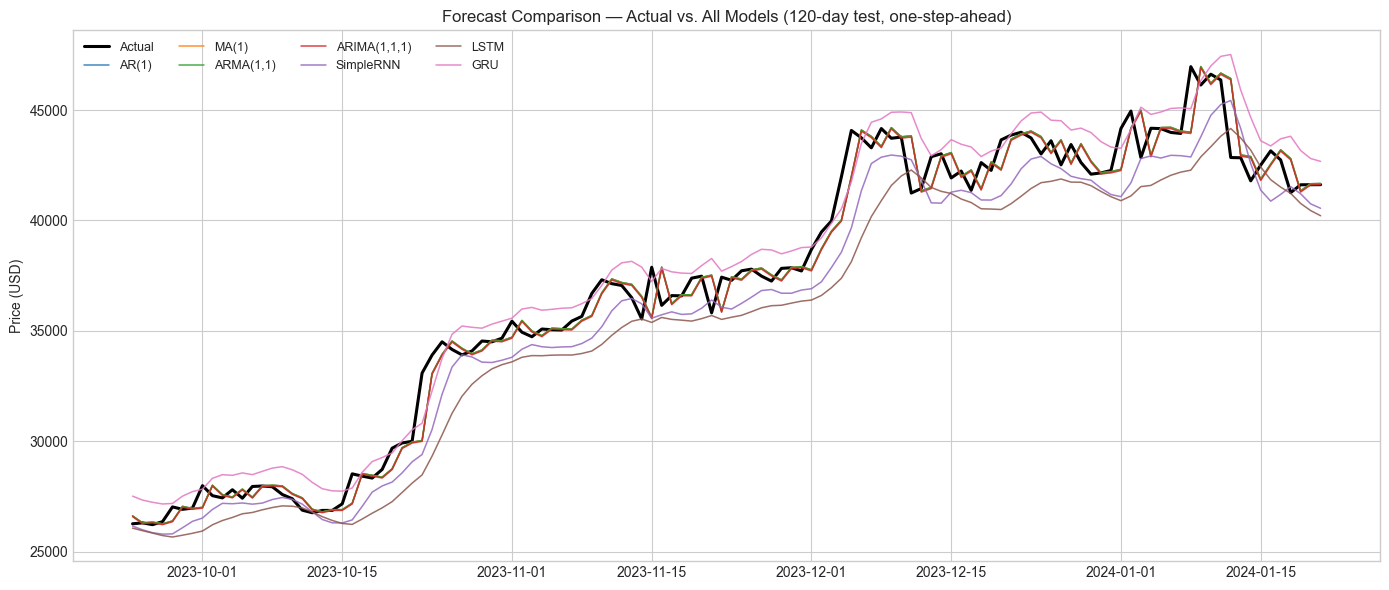

In [25]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, actual_price, label="Actual", color="black", lw=2.2)
palette = plt.cm.tab10(np.linspace(0, 1, len(order_models)))
for c, name in zip(palette, order_models):
    plt.plot(test.index, results[name]["pred"], label=name, lw=1.1, alpha=0.85)
plt.title("Forecast Comparison — Actual vs. All Models (120-day test, one-step-ahead)")
plt.ylabel("Price (USD)"); plt.legend(ncol=4, fontsize=9); plt.tight_layout(); plt.show()

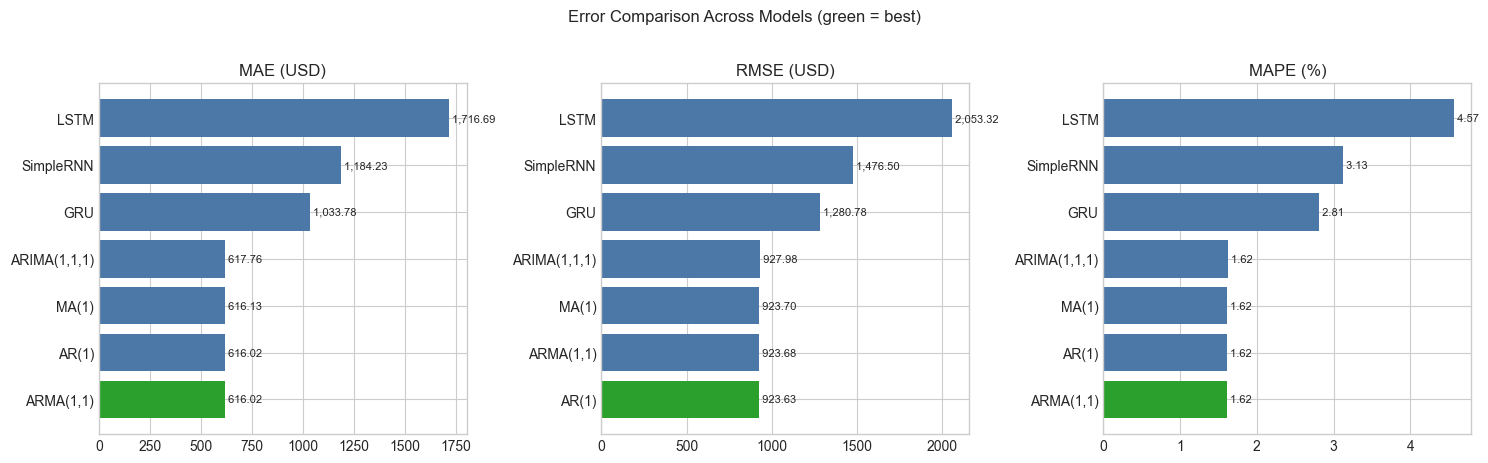

In [26]:
# Error comparison bar charts: MAE, RMSE, MAPE.
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for a, col, title in zip(ax, ["MAE", "RMSE", "MAPE_%"], ["MAE (USD)", "RMSE (USD)", "MAPE (%)"]):
    m = metrics[col].sort_values()
    colors = ["#2ca02c" if v == m.min() else "#4c78a8" for v in m.values]
    a.barh(m.index, m.values, color=colors)
    a.set_title(title)
    for i, v in enumerate(m.values):
        a.text(v, i, f" {v:,.2f}", va="center", fontsize=8)
plt.suptitle("Error Comparison Across Models (green = best)", y=1.02)
plt.tight_layout(); plt.show()

### Residual analysis (all models)
For each model we plot the test residuals and their ACF, and run a Ljung–Box test to judge whether the
residuals behave like **white noise** (no remaining autocorrelation).

AR(1)            Ljung-Box(10) p=0.790 -> white noise
MA(1)            Ljung-Box(10) p=0.788 -> white noise
ARMA(1,1)        Ljung-Box(10) p=0.789 -> white noise
ARIMA(1,1,1)     Ljung-Box(10) p=0.779 -> white noise
SimpleRNN        Ljung-Box(10) p=0.000 -> autocorrelation remains
LSTM             Ljung-Box(10) p=0.000 -> autocorrelation remains
GRU              Ljung-Box(10) p=0.001 -> autocorrelation remains


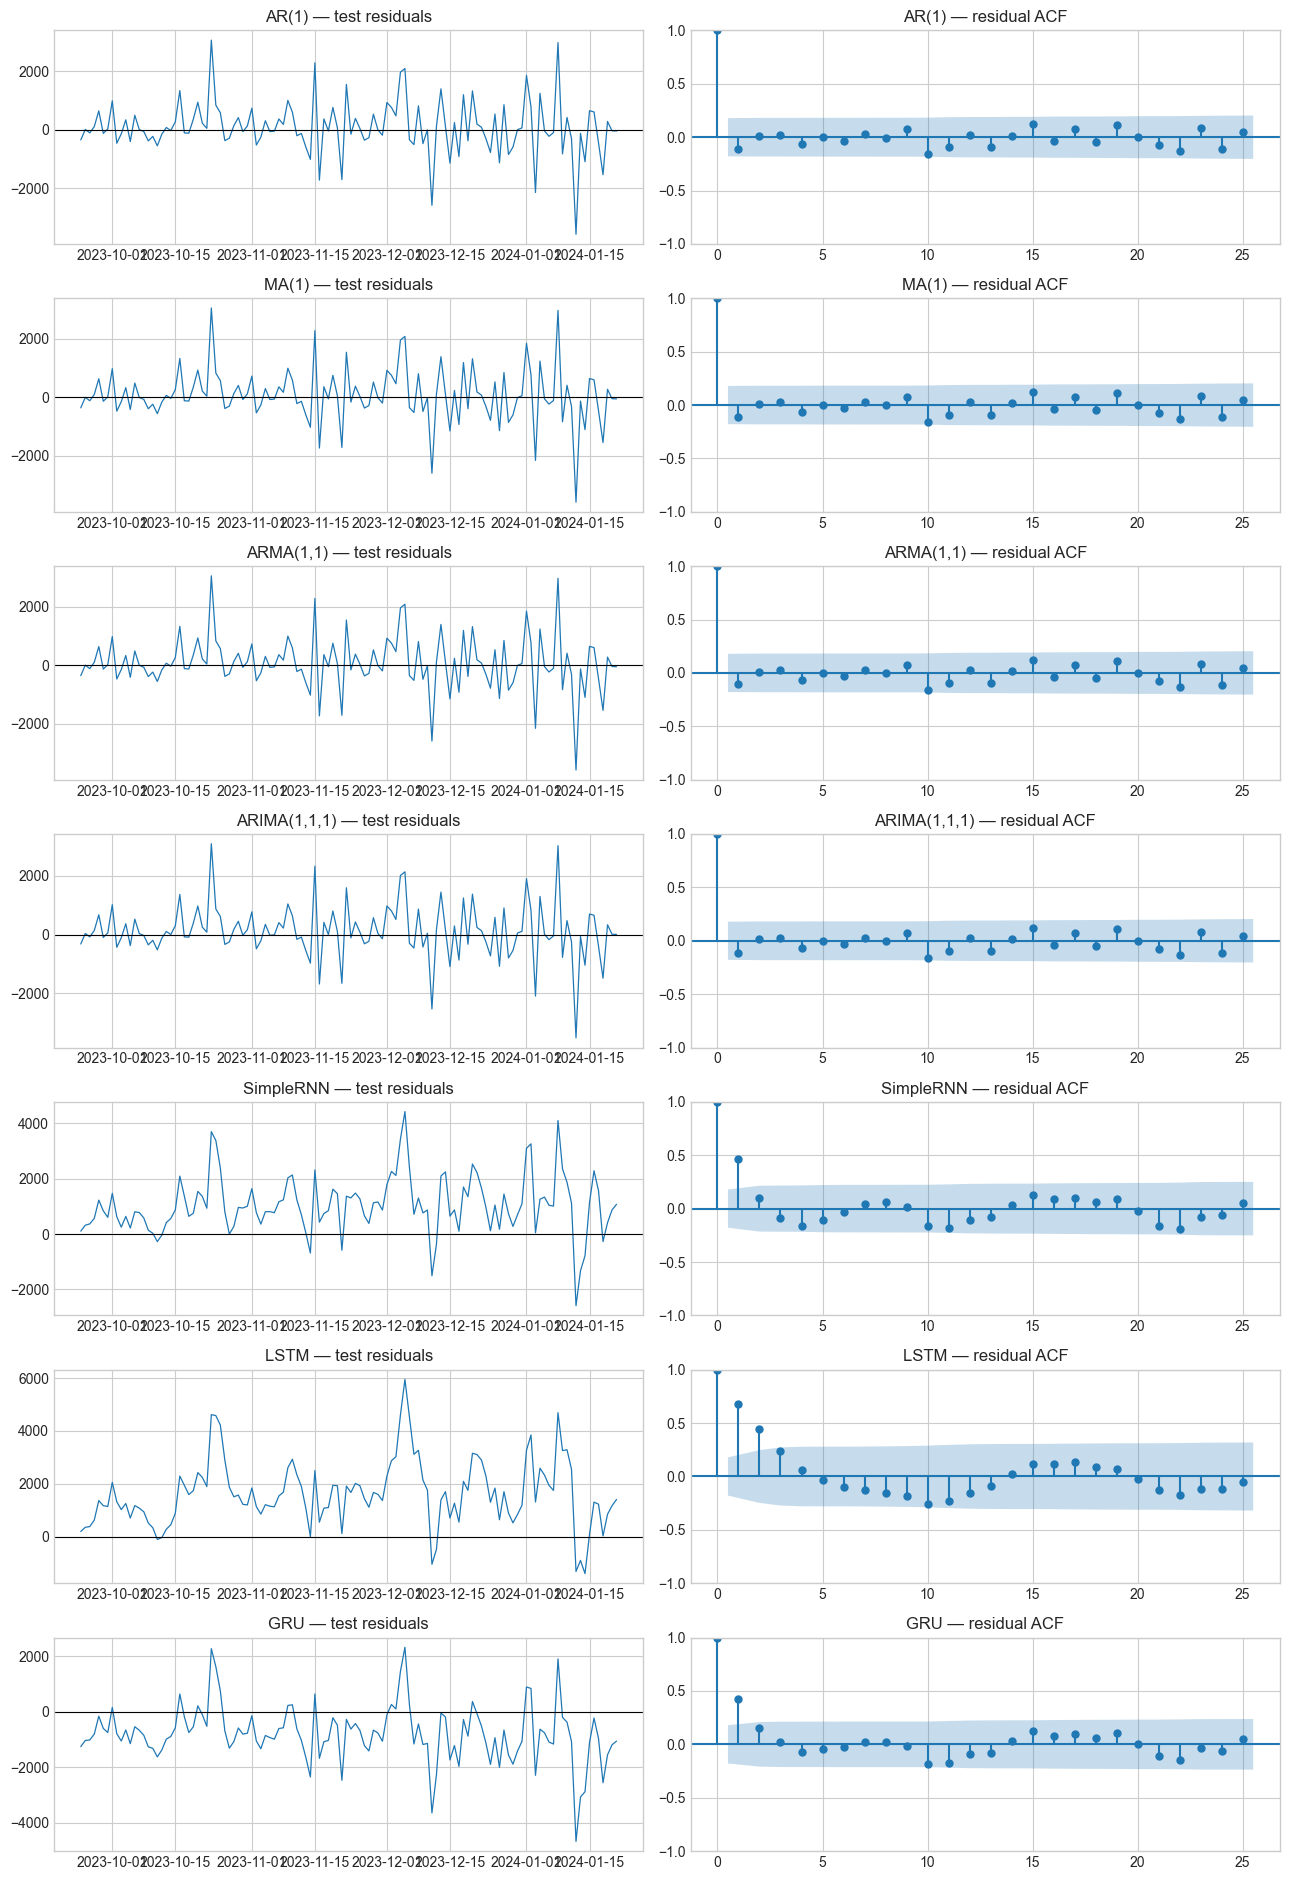

In [27]:
fig, axes = plt.subplots(len(order_models), 2, figsize=(13, 2.7*len(order_models)))
for row, name in enumerate(order_models):
    resid = results[name]["resid"]
    axes[row, 0].plot(test.index, resid, color="#1f77b4", lw=0.9)
    axes[row, 0].axhline(0, color="k", lw=0.8)
    axes[row, 0].set_title(f"{name} — test residuals")
    plot_acf(resid, lags=25, ax=axes[row, 1]); axes[row, 1].set_title(f"{name} — residual ACF")
    lb = acorr_ljungbox(resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    print(f"{name:16s} Ljung-Box(10) p={lb:.3f} -> "
          f"{'white noise' if lb > 0.05 else 'autocorrelation remains'}")
plt.tight_layout(); plt.show()

**Residual interpretation (all models).** The **classical** models pass the white-noise test: their
test residuals are centred on zero, their ACFs sit inside the confidence band, and the Ljung–Box
p-values are > 0.05 — they behave like a random walk's one-step errors, which is the best achievable
here. The **RNN/LSTM/GRU** residuals, by contrast, show **significant autocorrelation** (Ljung–Box
p ≈ 0): the networks learn a slightly **lagged / smoothed** copy of the price, so consecutive errors
are correlated and systematically larger. This is exactly why the neural models score worse on the
metrics — the residual diagnostics and the error table tell a consistent story.

# Part VIII – Discussion and Conclusions

**1. Which model achieved the best forecasting performance?**
On this run the **classical models won clearly**: AR(1), ARMA(1,1) and MA(1) tied for the lowest error
(MAE ≈ \$616, RMSE ≈ \$924, **MAPE ≈ 1.6 %**), with ARIMA(1,1,1) essentially equal. The neural models
trailed (GRU ≈ 2.8 %, SimpleRNN ≈ 3.1 %, LSTM ≈ 4.6 % MAPE). The reason is structural: for a
near-random-walk series the best one-step forecast of tomorrow's price is essentially *today's* price,
which is exactly what the differenced linear models reproduce. There is little linear *or* nonlinear
signal left to exploit, so added model complexity only adds error.

**2. Did ACF and PACF correctly guide model-order selection?**
Yes. The ACF/PACF of the differenced-log series lay almost entirely inside the 95 % confidence band,
correctly signalling that BTC log-returns are close to white noise and that **low** AR/MA orders
(p = q = 1) suffice. They also correctly *forewarned* that the linear models would barely beat a naïve
random walk — confirmed by the white-noise residuals in Part VII.

**3. How did AR, MA, ARMA, ARIMA compare against RNN-based forecasting?**
The classical family **outperformed** the RNN family here. ARMA(1,1) and ARIMA(1,1,1) were nearly
identical (as expected — see Part IV), confirming the equivalence of "difference-then-ARMA" and
"ARIMA-with-d=1". The RNNs underperformed not because they are weaker models in general, but because
they learned a slightly **lagged** representation of the price (their residuals retain autocorrelation,
Part VII); on a series with genuine nonlinear or long-memory structure their flexibility would pay off.

**4. Advantages and limitations of classical statistical models.**
*Advantages:* fast, interpretable, few parameters, solid theory, confidence intervals, and — as seen
here — a very strong baseline on linear/near-random-walk data with limited signal. *Limitations:*
assume linearity and (after differencing) stationarity; cannot capture nonlinear dynamics; multi-step
forecasts of a random walk collapse to a flat drift.

**5. Advantages and limitations of deep-learning models.**
*Advantages:* capture nonlinear and long-range dependencies, flexible, scale to multivariate inputs and
large datasets, no explicit stationarity assumption. *Limitations:* data- and compute-hungry, many
hyper-parameters, prone to over-fitting and to learning a lagged copy on noisy series, less
interpretable, and — as demonstrated here — they offer **no benefit, and can do worse,** when the
signal is essentially linear/random.

**6. When to prefer ARIMA vs. RNN.**
Prefer **ARIMA** when the data is limited, roughly linear/stationary after differencing, when
interpretability and uncertainty estimates matter, or when compute is constrained — a strong, cheap
baseline (and the winner on this dataset). Prefer **RNN/LSTM/GRU** when there is abundant data with
nonlinear or long-memory structure, multiple input features, or when squeezing out extra accuracy
justifies the higher complexity and training cost.

**Overall conclusion.** Bitcoin's daily price behaves close to a random walk: differencing the log
price yields a near-white-noise series, so the simple classical models — which reduce to the
persistence (random-walk) forecast — achieved the best one-step accuracy (≈ 1.6 % MAPE), while the more
complex RNNs added error by lagging the signal. The exercise demonstrates the complete, correct
workflow end-to-end — exploration → stationarisation → order selection → classical modelling → deep
learning → rigorous, like-for-like evaluation — and a key practical lesson: **match model complexity to
the structure actually present in the data.**